# 

In [54]:
import pandas as pd
import requests
import urllib3

# Disable SSL warnings (unsafe for production)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# API endpoint
url = "https://register.lowcarboncontracts.uk/api/v1/contracts?format=json"

try:
    # Make GET request (ignore SSL validation)
    response = requests.get(url, verify=False)
    print("Status Code:", response.status_code)

    # Parse JSON
    data = response.json()

    # Convert to DataFrame
    df_cfd = pd.DataFrame(data)
    print(f"Loaded {len(df_cfd)} records into df_cfd")

    # Preview first few rows
    print(df_cfd.head())

except Exception as e:
    print("Error:", e)

Status Code: 200
Loaded 413 records into df_cfd
    id current_installed_capacity  contract_id    allocation_round scheme  \
0  215                      11.94  AAA-LIG-176  Allocation Round 1    CfD   
1    2                       49.9  AR5-ASH-700  Allocation Round 5    CfD   
2   19                        1.5  AR5-EMB-500  Allocation Round 5    CfD   
3   66                       67.2  AR5-BLW-610  Allocation Round 5    CfD   
4   31                      35.71  AR5-LAN-700  Allocation Round 5    CfD   

               counterparty_name counterparty_registration_no  \
0       GSII Chafarm CFD Limited                     08769576   
1  JBM SOLAR PROJECTS 24 LIMITED                     12433921   
2    MAGALLANES TIDAL ENERGY LTD                     SC661403   
3    BLARGHOUR WIND FARM LIMITED                     09171723   
4       JBM SOLAR PROJECTS 2 LTD                     11761556   

                                counterparty_address             project_name  \
0  27 Old Glouces

In [55]:
# %pip install openpyxl

# import pandas as pd

# df_cfd = pd.read_excel(r"C:\Repos\rencal\rencal\data\CfD_Register.xlsx")

# display(df_cfd.head())
# print(df_cfd.shape)


In [56]:
df_cfd_filtered = df_cfd[df_cfd["technology_type"].isin(["Onshore Wind", "Offshore Wind"])][
    ["contract_id", "latitude", "longitude", "technology_type", "current_installed_capacity"]
]

# Ensure latitude and longitude are numeric (convert strings to floats, set invalid ones to NaN)
df_cfd_filtered["latitude"] = pd.to_numeric(df_cfd_filtered["latitude"], errors="coerce")
df_cfd_filtered["longitude"] = pd.to_numeric(df_cfd_filtered["longitude"], errors="coerce")

display(df_cfd_filtered)

,contract_id,latitude,longitude,technology_type,current_installed_capacity
3,AR5-BLW-610,56.27875,-5.16675,Onshore Wind,67.2
8,AAA-PNE-187,55.23900,-4.80125,Onshore Wind,18.684
9,AAA-COI-196,57.79100,-4.37750,Onshore Wind,30
15,AAA-BAN-192,55.50500,-3.80025,Onshore Wind,50.73
16,AR5-FEW-610,55.13100,-3.99100,Onshore Wind,50
...,...,...,...,...,...
376,AR6-MOW-010,58.10925,-2.91275,Offshore Wind,73.5
394,AR6-KHW-600,55.31300,-4.73750,Onshore Wind,7.05
397,AR6-TAT-600,58.40675,-3.41675,Onshore Wind,12.9
398,AR6-CHW-610,58.12275,-4.35225,Onshore Wind,96


In [57]:
df_cfd_filtered = df_cfd_filtered.rename(
    columns={
        "contract_id": "CFD_Id",
        "latitude": "Latitude",
        "longitude": "Longitude",
        "technology_type": "Technology",
        "current_installed_capacity": "Maximum Capacity",
    }
)

display(df_cfd_filtered)

,CFD_Id,Latitude,Longitude,Technology,Maximum Capacity
3,AR5-BLW-610,56.27875,-5.16675,Onshore Wind,67.2
8,AAA-PNE-187,55.23900,-4.80125,Onshore Wind,18.684
9,AAA-COI-196,57.79100,-4.37750,Onshore Wind,30
15,AAA-BAN-192,55.50500,-3.80025,Onshore Wind,50.73
16,AR5-FEW-610,55.13100,-3.99100,Onshore Wind,50
...,...,...,...,...,...
376,AR6-MOW-010,58.10925,-2.91275,Offshore Wind,73.5
394,AR6-KHW-600,55.31300,-4.73750,Onshore Wind,7.05
397,AR6-TAT-600,58.40675,-3.41675,Onshore Wind,12.9
398,AR6-CHW-610,58.12275,-4.35225,Onshore Wind,96


In [58]:
import pandas as pd

url = "https://dp.lowcarboncontracts.uk/dataset/be8c542a-c66c-4a06-a3df-bc46db7416c0/resource/9316f493-365c-4abc-a40e-3a5e67119a0a/download/cfd_to_bm_unit_mapping.csv"
bmu_mapping = pd.read_csv(url)

display(bmu_mapping)

,CFD_Id,BMU_Id,Effective_From,Effective_date_to
0,AAA-ACH-183,C__PSMAR001,2018-06-16 00:00:00.0000000,NaN
1,AAA-BAD-185,T_BDCHW-1,2018-12-01 00:00:00.0000000,NaN
2,AAA-BAN-189,T_KPMRW-1,2018-10-12 00:00:00.0000000,NaN
3,AAA-BAN-190,C__FCMRO003,2025-03-01 00:00:00.0000000,NaN
4,AAA-BAN-190,C__FENRG003,2022-12-01 00:00:00.0000000,2025-02-28 00:00:00.0000000
...,...,...,...,...
103,INV-LYN-001,E_LYNE3,2017-07-14 00:00:00.0000000,NaN
104,INV-TEE-001,C__FNATP012,2020-06-01 00:00:00.0000000,NaN
105,INV-TEE-001,T_TSREP-1,2020-06-01 00:00:00.0000000,NaN
106,INV-WAL-001,T_WLNYO-3,2017-08-15 00:00:00.0000000,NaN


In [59]:
bmu_mapping_filtered = bmu_mapping[["CFD_Id", "BMU_Id"]]

display(bmu_mapping_filtered)

,CFD_Id,BMU_Id
0,AAA-ACH-183,C__PSMAR001
1,AAA-BAD-185,T_BDCHW-1
2,AAA-BAN-189,T_KPMRW-1
3,AAA-BAN-190,C__FCMRO003
4,AAA-BAN-190,C__FENRG003
...,...,...
103,INV-LYN-001,E_LYNE3
104,INV-TEE-001,C__FNATP012
105,INV-TEE-001,T_TSREP-1
106,INV-WAL-001,T_WLNYO-3


In [60]:
df_filtered = df_cfd_filtered.merge(bmu_mapping_filtered, on="CFD_Id", how="inner")
display(df_filtered)

,CFD_Id,Latitude,Longitude,Technology,Maximum Capacity,BMU_Id
0,AAA-PNE-187,55.23900,-4.80125,Onshore Wind,18.684,T_TRLGW-1
1,AAA-COI-196,57.79100,-4.37750,Onshore Wind,30,C__PIMPO008
2,AAA-COI-196,57.79100,-4.37750,Onshore Wind,30,E_CNCLW-1
3,AAA-BAN-192,55.50500,-3.80025,Onshore Wind,50.73,C__NMAGN007
4,AAA-BAN-192,55.50500,-3.80025,Onshore Wind,50.73,T_MIDMW-1
...,...,...,...,...,...,...
66,AR2-MRY-207,58.14750,-2.78350,Offshore Wind,309.363,T_MOWEO-3
67,AR2-MRY-307,58.12475,-2.78350,Offshore Wind,318.77,T_MOWEO-1
68,AR2-MRY-307,58.12475,-2.78350,Offshore Wind,318.77,T_MOWEO-2
69,AR2-MRY-307,58.12475,-2.78350,Offshore Wind,318.77,T_MOWEO-3


# Running BMU API call for generation

In [ ]:
from datetime import UTC, datetime, timedelta

import pandas as pd
import requests

# --- API setup ---
URL = "https://data.elexon.co.uk/bmrs/api/v1/datasets/B1610/stream"

start_utc = "2023-01-01T00:00:00Z"  # This needs to start when ERA5 data starts to align properly
to_utc = (datetime.now(UTC) - timedelta(days=5)).strftime("%Y-%m-%dT%H:%M:%SZ")

# Use BMU_Id from df_filtered directly
bmu_ids = df_filtered["BMU_Id"].unique().tolist()

params = {"from": start_utc, "to": to_utc, "bmUnit": bmu_ids, "format": "json"}

# --- Fetch ---
r = requests.get(URL, params=params, timeout=60, verify=False)
r.raise_for_status()
payload = r.json()

# --- Parse ---
rows = payload if isinstance(payload, list) else payload.get("data", [])
df = pd.DataFrame(rows)

# --- Clean ---
df["settlementDate"] = pd.to_datetime(df["settlementDate"]).dt.date
df["settlementPeriod"] = pd.to_numeric(df["settlementPeriod"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

# --- Normalise BMU column ---
df.rename(columns={"bmUnit": "BMU_Id"}, inplace=True)

# --- Keep individual BMU quantities ---
df_individual = df[["settlementDate", "settlementPeriod", "BMU_Id", "quantity"]].copy()

print("Individual BMU dataset created.")
print(df_individual.head())

✅ Individual BMU dataset created.
  settlementDate  settlementPeriod       BMU_Id  quantity
0     2023-01-01                 1  C__PSMAR001     0.000
1     2023-01-01                 1  C__PSTAT011     4.090
2     2023-01-01                 1    E_CNCLW-1     1.223
3     2023-01-01                 1    E_SWBKW-1    12.800
4     2023-01-01                 1    T_BDCHW-1    -0.088


In [62]:
# --- Append CFD_Id from df_filtered ---
df_final = df_individual.merge(df_filtered[["BMU_Id", "CFD_Id"]], on="BMU_Id", how="left")

In [63]:
display(df_final)

,settlementDate,settlementPeriod,BMU_Id,quantity,CFD_Id
0,2023-01-01,1,C__PSMAR001,0.000,AAA-ACH-183
1,2023-01-01,1,C__PSTAT011,4.090,AAA-NAN-184
2,2023-01-01,1,E_CNCLW-1,1.223,AAA-COI-196
3,2023-01-01,1,E_SWBKW-1,12.800,AAA-SOL-181
4,2023-01-01,1,T_BDCHW-1,-0.088,AAA-BAD-185
...,...,...,...,...,...
2485527,2025-10-23,48,T_TKNWW-1,205.510,AR2-TKN-103
2485528,2025-10-23,48,T_TKNWW-1,205.510,AR2-TKN-303
2485529,2025-10-23,48,T_TRLGW-1,1.759,AAA-PNE-187
2485530,2025-10-23,48,T_WLNYO-3,147.330,INV-WAL-001


In [ ]:
# --- Aggregate BMUs by CFD_Id, Settlement Date & Period ---
df_cfd_total = df_final.groupby(["CFD_Id", "settlementDate", "settlementPeriod"], as_index=False)[
    "quantity"
].sum()

# Round all quantity values to 2 decimal places
df_cfd_total["quantity"] = df_cfd_total["quantity"].round(2)

# --- Sort so that settlement periods come first, then CfDs ---
df_cfd_total = df_cfd_total.sort_values(
    by=["settlementDate", "settlementPeriod", "CFD_Id"], ascending=[True, True, True]
).reset_index(drop=True)

print(" Aggregated and ordered dataset created (quantities rounded to 2dp).")
display(df_cfd_total)

✅ Aggregated and ordered dataset created (quantities rounded to 2dp).


,CFD_Id,settlementDate,settlementPeriod,quantity
0,AAA-ACH-183,2023-01-01,1,0.00
1,AAA-BAD-185,2023-01-01,1,-0.09
2,AAA-BAN-189,2023-01-01,1,16.63
3,AAA-BAN-192,2023-01-01,1,4.21
4,AAA-COI-196,2023-01-01,1,1.22
...,...,...,...,...
1659865,INV-HOR-001,2025-10-23,48,199.84
1659866,INV-HOR-002,2025-10-23,48,199.38
1659867,INV-HOR-003,2025-10-23,48,199.66
1659868,INV-WAL-001,2025-10-23,48,147.33


In [65]:
import pandas as pd

# --- Create hour index (each hour = 2 settlement periods) ---
df_cfd_total["hour_index"] = (df_cfd_total["settlementPeriod"] - 1) // 2

# --- Sum quantities across both settlement periods for each hour ---
hourly_gen = df_cfd_total.groupby(["CFD_Id", "settlementDate", "hour_index"], as_index=False)[
    "quantity"
].sum()

# --- Create actual datetime for clarity ---
hourly_gen["Times"] = pd.to_datetime(hourly_gen["settlementDate"]) + pd.to_timedelta(
    hourly_gen["hour_index"], unit="h"
)

# --- Round to 2 decimal places ---
hourly_gen["quantity"] = hourly_gen["quantity"].round(2)

print("✅ Hourly generation (MWh) calculated from df_cfd_total.")
display(hourly_gen.head(10))

✅ Hourly generation (MWh) calculated from df_cfd_total.


,CFD_Id,settlementDate,hour_index,quantity,Times
0,AAA-ACH-183,2023-01-01,0,0.00,2023-01-01 00:00:00
1,AAA-ACH-183,2023-01-01,1,0.00,2023-01-01 01:00:00
2,AAA-ACH-183,2023-01-01,2,0.00,2023-01-01 02:00:00
3,AAA-ACH-183,2023-01-01,3,0.00,2023-01-01 03:00:00
4,AAA-ACH-183,2023-01-01,4,0.13,2023-01-01 04:00:00
5,AAA-ACH-183,2023-01-01,5,0.09,2023-01-01 05:00:00
6,AAA-ACH-183,2023-01-01,6,0.00,2023-01-01 06:00:00
7,AAA-ACH-183,2023-01-01,7,0.00,2023-01-01 07:00:00
8,AAA-ACH-183,2023-01-01,8,0.04,2023-01-01 08:00:00
9,AAA-ACH-183,2023-01-01,9,0.02,2023-01-01 09:00:00


In [66]:
display(df_cfd_total)

,CFD_Id,settlementDate,settlementPeriod,quantity,hour_index
0,AAA-ACH-183,2023-01-01,1,0.00,0
1,AAA-BAD-185,2023-01-01,1,-0.09,0
2,AAA-BAN-189,2023-01-01,1,16.63,0
3,AAA-BAN-192,2023-01-01,1,4.21,0
4,AAA-COI-196,2023-01-01,1,1.22,0
...,...,...,...,...,...
1659865,INV-HOR-001,2025-10-23,48,199.84,23
1659866,INV-HOR-002,2025-10-23,48,199.38,23
1659867,INV-HOR-003,2025-10-23,48,199.66,23
1659868,INV-WAL-001,2025-10-23,48,147.33,23


# Usual script from now on

In [67]:
# ====== Install packages ======
%pip install netCDF4
%pip install scipy
%pip install seaborn
%pip install scikit-learn

# ====== Imports ======
# Standard library
import os
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt

# Scientific + plotting
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.stats import weibull_min

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
def process_file(file_path, wind_farm_df):
    """
    Process a NetCDF file containing wind speed components and extract
    time series of wind speeds for given wind farm locations. We will
    use this function to loop through multiple NetCDF files later.

    Parameters
    ----------
    file_path : str
        Path to the NetCDF file containing wind speed data. The file
        must include the variables 'longitude', 'latitude', 'time',
        'u100', and 'v100'.
    wind_farm_df : pandas.DataFrame
        DataFrame containing wind farm metadata. Must include columns:
        - 'Longitude' : float, longitude of the wind farm
        - 'Latitude'  : float, latitude of the wind farm
        - 'CFD ID'    : identifier of the wind farm (e.g., string or int)

    Returns
    -------
    pandas.DataFrame
        A DataFrame with columns:
        - 'Times'      : datetime, timestamps of observations
        - 'CFD ID'     : identifier for each wind farm
        - 'Wind Speed' : computed wind speed (m/s) at 100m height
          at the nearest grid point to each wind farm.

    Notes
    -----
    - Wind speed is computed as sqrt(U^2 + V^2), where U and V are
      the eastward and northward wind components, respectively.
    - The function maps each wind farm location to the nearest grid
      point in the NetCDF file.
    """
    with Dataset(file_path, mode="r") as nc:
        # Rename valid_time → time if needed
        if "valid_time" in nc.variables and "time" not in nc.variables:
            nc.variables["time"] = nc.variables["valid_time"]

        lon = nc.variables["longitude"][:]
        lat = nc.variables["latitude"][:]

        # Decode ERA5 valid_time properly (seconds since 1970-01-01)
        tvar = nc.variables["time"][:]
        timestamps = pd.to_datetime(tvar, unit="s", utc=True).tz_localize(None)

        # Wind components
        U = nc.variables["u100"][:]
        V = nc.variables["v100"][:]
        WS = np.sqrt(U**2 + V**2)  # shape (T, LAT, LON)

        # Wind farm info
        farm_lons = wind_farm_df["Longitude"].to_numpy()
        farm_lats = wind_farm_df["Latitude"].to_numpy()
        cfd_ids = wind_farm_df["CFD ID"].to_numpy()

        # Nearest grid point indices
        lon_idx = np.argmin(np.abs(lon[None, :] - farm_lons[:, None]), axis=1)
        lat_idx = np.argmin(np.abs(lat[None, :] - farm_lats[:, None]), axis=1)

        # Extract all farm wind speeds at once
        ws_all = WS[:, lat_idx, lon_idx]

        T = len(timestamps)
        N = len(cfd_ids)

        times_col = np.tile(timestamps, N)
        cfd_col = np.repeat(cfd_ids, T)
        ws_col = ws_all.reshape(-1, order="F")

        return pd.DataFrame({"Times": times_col, "CFD ID": cfd_col, "Wind Speed": ws_col})


def weibull(x, k, lamb):
    """
    Compute the probability density function (PDF) of the Weibull distribution.

    Parameters
    ----------
    x : float or array-like
        The value(s) at which to evaluate the Weibull PDF. Must be non-negative.
    k : float
        Shape parameter of the Weibull distribution (k > 0).
    lamb : float
        Scale parameter of the Weibull distribution (λ > 0).

    Returns
    -------
    float or numpy.ndarray
        The Weibull probability density value(s) evaluated at `x`.

    Notes
    -----
    The Weibull PDF is defined as:

        f(x; k, λ) = (k / λ) * (x / λ)^(k - 1) * exp[-(x / λ)^k]

    for x ≥ 0, k > 0, and λ > 0.
    """
    return (k / lamb) * (x / lamb) ** (k - 1) * np.exp(-((x / lamb) ** k))

In [69]:
# --- Local directory path ---
directory = Path(r"C:\Repos\rencal\rencal\data")

# --- Get all .nc files ---
files = [f for f in os.listdir(directory) if f.endswith(".nc")]

print(f"Found {len(files)} .nc files:")
for f in files:
    print(f)

Found 1 .nc files:
ERA5_UK_2023.nc


In [70]:
df_filtered = df_filtered.rename(columns={"CFD_Id": "CFD ID"})

In [71]:
df_filtered

,CFD ID,Latitude,Longitude,Technology,Maximum Capacity,BMU_Id
0,AAA-PNE-187,55.23900,-4.80125,Onshore Wind,18.684,T_TRLGW-1
1,AAA-COI-196,57.79100,-4.37750,Onshore Wind,30,C__PIMPO008
2,AAA-COI-196,57.79100,-4.37750,Onshore Wind,30,E_CNCLW-1
3,AAA-BAN-192,55.50500,-3.80025,Onshore Wind,50.73,C__NMAGN007
4,AAA-BAN-192,55.50500,-3.80025,Onshore Wind,50.73,T_MIDMW-1
...,...,...,...,...,...,...
66,AR2-MRY-207,58.14750,-2.78350,Offshore Wind,309.363,T_MOWEO-3
67,AR2-MRY-307,58.12475,-2.78350,Offshore Wind,318.77,T_MOWEO-1
68,AR2-MRY-307,58.12475,-2.78350,Offshore Wind,318.77,T_MOWEO-2
69,AR2-MRY-307,58.12475,-2.78350,Offshore Wind,318.77,T_MOWEO-3


In [72]:
results = []  # list to hold processed data from each file

# Loop through the files, filter for .nc files, and append data to the list
for file in files:
    if file.endswith(".nc"):
        file_path = os.path.join(directory, file)
        data = process_file(file_path, df_filtered)
        results.append(data)

final_results = pd.concat(results, ignore_index=True)

In [73]:
# Convert datetime to the specified format
# final_results['Times'] = pd.to_datetime(final_results['Times']).dt.tz_localize('UTC').dt.tz_convert('GMT')

In [74]:
final_results

,Times,CFD ID,Wind Speed
0,2023-01-01 00:00:00,AAA-PNE-187,8.558189
1,2023-01-01 01:00:00,AAA-PNE-187,7.427632
2,2023-01-01 02:00:00,AAA-PNE-187,7.060588
3,2023-01-01 03:00:00,AAA-PNE-187,5.720673
4,2023-01-01 04:00:00,AAA-PNE-187,3.970834
...,...,...,...
621955,2023-12-31 19:00:00,INV-HOR-003,14.836370
621956,2023-12-31 20:00:00,INV-HOR-003,15.037280
621957,2023-12-31 21:00:00,INV-HOR-003,14.366197
621958,2023-12-31 22:00:00,INV-HOR-003,14.963463


In [75]:
# Detect how many settlement periods per day exist
sp_counts = df_cfd_total.groupby("settlementDate")["settlementPeriod"].max().reset_index()
sp_counts.rename(columns={"settlementPeriod": "num_periods"}, inplace=True)

# Merge that back into your main dataframe
df = df_cfd_total.merge(sp_counts, on="settlementDate", how="left")

# Compute hour_index dynamically based on number of periods
# (Assume 2 SP/hour normally, but adjust proportionally for 46 or 50)
df["hour_index"] = ((df["settlementPeriod"] - 1) * 24 / df["num_periods"]).astype(int)

# Now aggregate to hourly
hourly = df.groupby(["settlementDate", "hour_index", "CFD_Id"], as_index=False)["quantity"].mean()

# Create UTC timestamp (assume settlementDate in UTC)
hourly["Times"] = (
    pd.to_datetime(hourly["settlementDate"]) + pd.to_timedelta(hourly["hour_index"], unit="h")
).dt.tz_localize("UTC")

hourly = hourly[["Times", "CFD_Id", "quantity"]].sort_values(by=["Times", "CFD_Id"])

print("✅ Hourly dataset created (BST transitions handled).")
display(hourly.head())

✅ Hourly dataset created (BST transitions handled).


,Times,CFD_Id,quantity
0,2023-01-01 00:00:00+00:00,AAA-ACH-183,0.00
1,2023-01-01 00:00:00+00:00,AAA-BAD-185,-0.09
2,2023-01-01 00:00:00+00:00,AAA-BAN-189,16.25
3,2023-01-01 00:00:00+00:00,AAA-BAN-192,4.42
4,2023-01-01 00:00:00+00:00,AAA-COI-196,1.47


In [76]:
display(hourly)

,Times,CFD_Id,quantity
0,2023-01-01 00:00:00+00:00,AAA-ACH-183,0.000
1,2023-01-01 00:00:00+00:00,AAA-BAD-185,-0.090
2,2023-01-01 00:00:00+00:00,AAA-BAN-189,16.250
3,2023-01-01 00:00:00+00:00,AAA-BAN-192,4.420
4,2023-01-01 00:00:00+00:00,AAA-COI-196,1.470
...,...,...,...
829963,2025-10-23 23:00:00+00:00,INV-HOR-001,199.800
829964,2025-10-23 23:00:00+00:00,INV-HOR-002,199.365
829965,2025-10-23 23:00:00+00:00,INV-HOR-003,199.640
829966,2025-10-23 23:00:00+00:00,INV-WAL-001,147.450


In [77]:
import pandas as pd

# --- 0) Ensure comparable types (timezone-aware & consistent keys)
final_results["Times"] = pd.to_datetime(final_results["Times"], utc=True)
hourly["Times"] = pd.to_datetime(hourly["Times"], utc=True)

# ✅ Handle both possible column names: "CFD ID" or "CFD_Id"
if "CFD ID" in final_results.columns:
    final_results.rename(columns={"CFD ID": "CFD_Id"}, inplace=True)
if "CFD ID" in hourly.columns:
    hourly.rename(columns={"CFD ID": "CFD_Id"}, inplace=True)

final_results["CFD_Id"] = final_results["CFD_Id"].astype(str)
hourly["CFD_Id"] = hourly["CFD_Id"].astype(str)

# --- 1) Collapse duplicates in hourly (if any)
hourly = hourly.groupby(["CFD_Id", "Times"], as_index=False, sort=False).agg({"quantity": "sum"})

# --- 2) Compute per-CFD time coverage in hourly
coverage = hourly.groupby("CFD_Id")["Times"].agg(hourly_start="min", hourly_end="max").reset_index()

# --- 3) Keep only CfDs that appear in hourly
valid_cfds = set(coverage["CFD_Id"].unique())
final_results = final_results[final_results["CFD_Id"].isin(valid_cfds)].copy()

# --- 4) Attach each CfD’s hourly window to final_results and filter by it
final_results = final_results.merge(coverage, on="CFD_Id", how="left")

mask = final_results["Times"].between(final_results["hourly_start"], final_results["hourly_end"])
final_results = final_results.loc[mask, ["Times", "CFD_Id", "Wind Speed"]].copy()

# --- 5) Merge for ALL CfDs within their own windows
merged = pd.merge(final_results, hourly, on=["Times", "CFD_Id"], how="left")

# --- 6) Compute Load Factor (each CfD vs its own max quantity)
merged["Load Factor"] = merged["quantity"].fillna(0) / merged.groupby("CFD_Id")[
    "quantity"
].transform("max")

print("✅ Merged dataset created (ALL CfDs, clipped to each CfD's hourly coverage):")
print(merged.head())
print(f"Rows kept: {len(merged):,}")
print(f"CfDs included: {merged['CFD_Id'].nunique():,}")

✅ Merged dataset created (ALL CfDs, clipped to each CfD's hourly coverage):
                      Times       CFD_Id  Wind Speed  quantity  Load Factor
0 2023-01-01 00:00:00+00:00  AAA-PNE-187    8.558189     0.775     0.082755
1 2023-01-01 01:00:00+00:00  AAA-PNE-187    7.427632     0.510     0.054458
2 2023-01-01 02:00:00+00:00  AAA-PNE-187    7.060588     0.145     0.015483
3 2023-01-01 03:00:00+00:00  AAA-PNE-187    5.720673    -0.020    -0.002136
4 2023-01-01 04:00:00+00:00  AAA-PNE-187    3.970834     0.155     0.016551
Rows kept: 482,856
CfDs included: 34


In [78]:
display(merged)

,Times,CFD_Id,Wind Speed,quantity,Load Factor
0,2023-01-01 00:00:00+00:00,AAA-PNE-187,8.558189,0.775,0.082755
1,2023-01-01 01:00:00+00:00,AAA-PNE-187,7.427632,0.510,0.054458
2,2023-01-01 02:00:00+00:00,AAA-PNE-187,7.060588,0.145,0.015483
3,2023-01-01 03:00:00+00:00,AAA-PNE-187,5.720673,-0.020,-0.002136
4,2023-01-01 04:00:00+00:00,AAA-PNE-187,3.970834,0.155,0.016551
...,...,...,...,...,...
482851,2023-12-31 19:00:00+00:00,INV-HOR-003,14.836370,188.305,0.943790
482852,2023-12-31 20:00:00+00:00,INV-HOR-003,15.037280,194.130,0.972985
482853,2023-12-31 21:00:00+00:00,INV-HOR-003,14.366197,191.060,0.957598
482854,2023-12-31 22:00:00+00:00,INV-HOR-003,14.963463,190.760,0.956095


In [79]:
# --- Compute per-CFD maximum quantity (handle either 'CFD ID' or 'CFD_Id') ---
cfd_col = "CFD_Id" if "CFD_Id" in merged.columns else "CFD ID"

max_per_cfd = merged.groupby(cfd_col)["quantity"].transform("max")

# --- Create the load-factor column ---
merged["Load Factor"] = merged["quantity"].fillna(0) / max_per_cfd

print("✅ Load Factor calculated successfully.")
print(merged.head())

✅ Load Factor calculated successfully.
                      Times       CFD_Id  Wind Speed  quantity  Load Factor
0 2023-01-01 00:00:00+00:00  AAA-PNE-187    8.558189     0.775     0.082755
1 2023-01-01 01:00:00+00:00  AAA-PNE-187    7.427632     0.510     0.054458
2 2023-01-01 02:00:00+00:00  AAA-PNE-187    7.060588     0.145     0.015483
3 2023-01-01 03:00:00+00:00  AAA-PNE-187    5.720673    -0.020    -0.002136
4 2023-01-01 04:00:00+00:00  AAA-PNE-187    3.970834     0.155     0.016551


In [80]:
# Create a DataFrame to hold the results
weibull_parameters_df = pd.DataFrame(columns=["CFD ID", "Mean", "Std Dev", "Lambda", "k"])

In [81]:
import pandas as pd

# --- Ensure consistent column naming ---
if "CFD ID" in final_results.columns:
    final_results.rename(columns={"CFD ID": "CFD_Id"}, inplace=True)

# --- Group by CFD_Id and compute wind speed stats ---
g = final_results.groupby("CFD_Id", sort=False)["Wind Speed"]

# --- Compute mean and standard deviation per CfD ---
stats = g.agg(Mean_Wind_Speed="mean", Wind_Speed_Std="std")


# --- Define a Weibull fitting function ---
def fit_one(item):
    cfd_id, s = item
    arr = s.dropna().values  # drop NaNs to avoid fit errors
    if len(arr) < 3:  # not enough points to fit reliably
        return cfd_id, np.nan, np.nan
    k, loc, lamb = weibull_min.fit(arr, floc=0)
    return cfd_id, k, lamb


# --- Parallel Weibull fits ---
with ThreadPoolExecutor(max_workers=8) as ex:
    fits = list(ex.map(fit_one, g))

fit_df = pd.DataFrame(fits, columns=["CFD_Id", "k", "Lambda"])

# --- Combine stats + Weibull parameters ---
weibull_parameters_df = stats.reset_index().merge(fit_df, on="CFD_Id", how="left", sort=False)

print("✅ Weibull parameter table created:")
print(weibull_parameters_df.head())

✅ Weibull parameter table created:
        CFD_Id  Mean_Wind_Speed  Wind_Speed_Std         k     Lambda
0  AAA-PNE-187         7.667506        3.728207  2.165362   8.656555
1  AAA-COI-196         5.660117        3.240637  1.815672   6.371606
2  AAA-BAN-192         6.796084        3.186390  2.250766   7.671385
3  AAA-NEA-195         8.380516        4.170014  2.089494   9.440019
4  AR4-BCW-610         9.881341        3.638036  2.966648  11.063517


In [82]:
# rename columns to desired titles
weibull_parameters_df = weibull_parameters_df.rename(
    columns={
        "Mean_Wind_Speed": "Mean Wind Speed",
        "Wind_Speed_Std": "Wind Speed Standard Deviation",
    }
)

# enforce exact column order
weibull_parameters_df = weibull_parameters_df[
    ["CFD_Id", "Lambda", "k", "Mean Wind Speed", "Wind Speed Standard Deviation"]
]

In [83]:
# ✅ Rename CFD_Id → CFD ID
merged.rename(columns={"CFD_Id": "CFD ID"}, inplace=True)

# ✅ Round all numeric columns to 2 decimal places
numeric_cols = merged.select_dtypes(include=["float", "int"]).columns
merged[numeric_cols] = merged[numeric_cols].round(2)

# ✅ Display updated dataframe
display(merged)

,Times,CFD ID,Wind Speed,quantity,Load Factor
0,2023-01-01 00:00:00+00:00,AAA-PNE-187,8.56,0.78,0.08
1,2023-01-01 01:00:00+00:00,AAA-PNE-187,7.43,0.51,0.05
2,2023-01-01 02:00:00+00:00,AAA-PNE-187,7.06,0.15,0.02
3,2023-01-01 03:00:00+00:00,AAA-PNE-187,5.72,-0.02,-0.00
4,2023-01-01 04:00:00+00:00,AAA-PNE-187,3.97,0.16,0.02
...,...,...,...,...,...
482851,2023-12-31 19:00:00+00:00,INV-HOR-003,14.84,188.30,0.94
482852,2023-12-31 20:00:00+00:00,INV-HOR-003,15.04,194.13,0.97
482853,2023-12-31 21:00:00+00:00,INV-HOR-003,14.37,191.06,0.96
482854,2023-12-31 22:00:00+00:00,INV-HOR-003,14.96,190.76,0.96


In [84]:
from concurrent.futures import ThreadPoolExecutor

import pandas as pd

# ✅ Rename CFD_Id → CFD ID
final_results.rename(columns={"CFD_Id": "CFD ID"}, inplace=True)

# --- Group by CFD ID and compute wind speed stats ---
g = final_results.groupby("CFD ID", sort=False)["Wind Speed"]

# --- Compute mean and std dev per CfD ---
stats = g.agg(Mean_Wind_Speed="mean", Wind_Speed_Std="std")


# --- Define Weibull fitting function ---
def fit_one(item):
    cfd_id, s = item
    arr = s.dropna().values
    if len(arr) < 3:  # skip if not enough points
        return cfd_id, np.nan, np.nan
    k, loc, lamb = weibull_min.fit(arr, floc=0)
    return cfd_id, k, lamb


# --- Parallel Weibull fits ---
with ThreadPoolExecutor(max_workers=8) as ex:
    fits = list(ex.map(fit_one, g))

fit_df = pd.DataFrame(fits, columns=["CFD ID", "k", "Lambda"])

# --- Combine stats + Weibull parameters ---
weibull_parameters_df = stats.reset_index().merge(fit_df, on="CFD ID", how="left", sort=False)

print("✅ Weibull parameter table created:")
print(weibull_parameters_df.head())

✅ Weibull parameter table created:
        CFD ID  Mean_Wind_Speed  Wind_Speed_Std         k     Lambda
0  AAA-PNE-187         7.667506        3.728207  2.165362   8.656555
1  AAA-COI-196         5.660117        3.240637  1.815672   6.371606
2  AAA-BAN-192         6.796084        3.186390  2.250766   7.671385
3  AAA-NEA-195         8.380516        4.170014  2.089494   9.440019
4  AR4-BCW-610         9.881341        3.638036  2.966648  11.063517


In [85]:
weibull_parameters_df

,CFD ID,Mean_Wind_Speed,Wind_Speed_Std,k,Lambda
0,AAA-PNE-187,7.667506,3.728207,2.165362,8.656555
1,AAA-COI-196,5.660117,3.240637,1.815672,6.371606
2,AAA-BAN-192,6.796084,3.186390,2.250766,7.671385
3,AAA-NEA-195,8.380516,4.170014,2.089494,9.440019
4,AR4-BCW-610,9.881341,3.638036,2.966648,11.063517
5,INV-HOR-001,9.523638,4.577934,2.189584,10.746810
6,AR2-HRN-206,9.499804,4.508522,2.219172,10.717412
7,AR2-HRN-106,9.510332,4.543072,2.203920,10.730492
8,INV-WAL-002,9.401438,4.569487,2.161272,10.606539
9,INV-DUD-002,9.334387,4.435550,2.225266,10.537419


In [ ]:
from pathlib import Path

import pandas as pd

summary = pd.DataFrame(columns=["CFD ID", "a", "b", "c", "d", "g", "Estimated Load Factor"])

# --- Loop once per unique CFD ID ---
for cfd_id in df_filtered["CFD ID"].unique():
    o = merged[merged["CFD ID"] == cfd_id].copy()
    params_weibull = weibull_parameters_df[weibull_parameters_df["CFD ID"] == cfd_id]

    # Skip if missing
    if o.empty or params_weibull.empty:
        print(f"Skipping {cfd_id} (no data or Weibull params).")
        continue

    # Drop rows with invalid values
    o = o.replace([np.inf, -np.inf], np.nan).dropna(subset=["Wind Speed", "Load Factor"])
    if o.empty:
        print(f"Skipping {cfd_id} (no valid numeric data).")
        continue

    # Clip extreme wind speeds to avoid overflow in power
    o = o[o["Wind Speed"].between(0, 40)]

    lambda_val = params_weibull["Lambda"].iloc[0]
    k_val = params_weibull["k"].iloc[0]

    # Logistic function
    def logistic_function(x, b, c, g):
        a, d = 0, 1
        return d + (a - d) / ((1 + (x / c) ** b) ** g)

    try:
        params, _ = curve_fit(
            logistic_function,
            o["Wind Speed"],
            o["Load Factor"],
            p0=[4.5, 9, 1],
            bounds=([0, 0, 0], [50, 50, 500]),  # tighter bounds for stability
            maxfev=10000,
        )
    except Exception as e:
        print(f"Skipping {cfd_id} (curve fit failed: {e})")
        continue

    # Integrate to get expected load factor
    try:
        estimated_load_factor = quad(
            lambda x: logistic_function(x, *params)
            * (k_val / lambda_val)
            * (x / lambda_val) ** (k_val - 1)
            * np.exp(-((x / lambda_val) ** k_val)),
            0,
            np.inf,
        )[0]
    except Exception as e:
        print(f"Integration failed for {cfd_id}: {e}")
        continue

    # Plot and save
    plt.figure(figsize=(8, 5))
    plt.scatter(o["Wind Speed"], o["Load Factor"], s=6, color="blue", alpha=0.5, label="Observed")
    x_vals = np.linspace(0, 25, 300)
    plt.plot(x_vals, logistic_function(x_vals, *params), color="orange", lw=2, label="Fitted Curve")

    mean_ws = o["Wind Speed"].mean()
    plt.axvline(
        mean_ws, color="green", linestyle="--", lw=1.5, label=f"Mean Wind = {mean_ws:.2f} m/s"
    )

    plt.title(f"Power Curve Fit – {cfd_id}")
    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Load Factor")
    plt.legend()
    plt.grid(True)

    path_name = Path(directory) / f"{cfd_id}.png"
    path_name.parent.mkdir(parents=True, exist_ok=True)
    # plt.savefig(path_name, dpi=150, bbox_inches="tight")
    plt.close()

    summary.loc[len(summary)] = [
        cfd_id,
        0,
        params[0],
        params[1],
        1,
        params[2],
        estimated_load_factor,
    ]

summary["Estimated Load Factor"] = summary["Estimated Load Factor"].round(4)
summary = summary.sort_values(by="Estimated Load Factor", ascending=False).reset_index(drop=True)

print("Done — curves fitted per CFD (duplicates removed).")
print(summary.head(10))

Skipping AAA-NEA-195 (no valid numeric data).
Skipping AAA-BAN-190 (no data or Weibull params).
Skipping AAA-COM-191 (no data or Weibull params).


C:\Users\StevensW\AppData\Local\Temp\ipykernel_13092\1544893222.py:37: RuntimeWarning: overflow encountered in scalar power
  return d + (a - d) / ((1 + (x / c)**b)**g)


Skipping AAA-BRE-177 (no data or Weibull params).


C:\Users\StevensW\AppData\Local\Temp\ipykernel_13092\1544893222.py:37: RuntimeWarning: overflow encountered in scalar power
  return d + (a - d) / ((1 + (x / c)**b)**g)
C:\Users\StevensW\AppData\Local\Temp\ipykernel_13092\1544893222.py:37: RuntimeWarning: overflow encountered in scalar power
  return d + (a - d) / ((1 + (x / c)**b)**g)


Skipping AAA-MYN-178 (no data or Weibull params).
Skipping AAA-CLO-186 (no data or Weibull params).
Skipping AAA-SNE-179 (no data or Weibull params).
Skipping AR4-HHR-610 (no data or Weibull params).
Done — curves fitted per CFD (duplicates removed).
        CFD ID  a         b          c  d           g  Estimated Load Factor
0  CAA-EAS-167  0  3.959861  48.502413  1  499.999982                 0.5141
1  CAA-EAS-166  0  3.959861  48.502413  1  499.999982                 0.5141
2  CAA-EAS-168  0  3.959861  48.502413  1  499.999982                 0.5141
3  INV-HOR-002  0  3.837628  15.475137  1    5.184515                 0.4905
4  INV-HOR-001  0  3.952282  17.389318  1    7.972171                 0.4791
5  INV-HOR-003  0  3.893123  33.240873  1   85.766062                 0.4698
6  INV-DUD-003  0  4.405645  11.386767  1    2.021516                 0.4670
7  INV-DUD-002  0  4.130409  13.684676  1    3.491272                 0.4622
8  INV-WAL-002  0  3.880126  13.213415  1    2.738816   

C:\Users\StevensW\AppData\Local\Temp\ipykernel_13092\1544893222.py:37: RuntimeWarning: overflow encountered in scalar power
  return d + (a - d) / ((1 + (x / c)**b)**g)


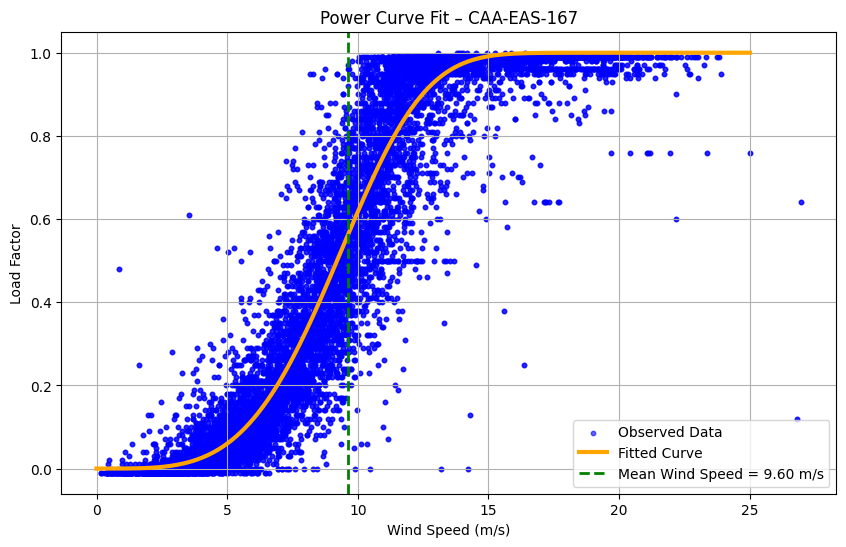

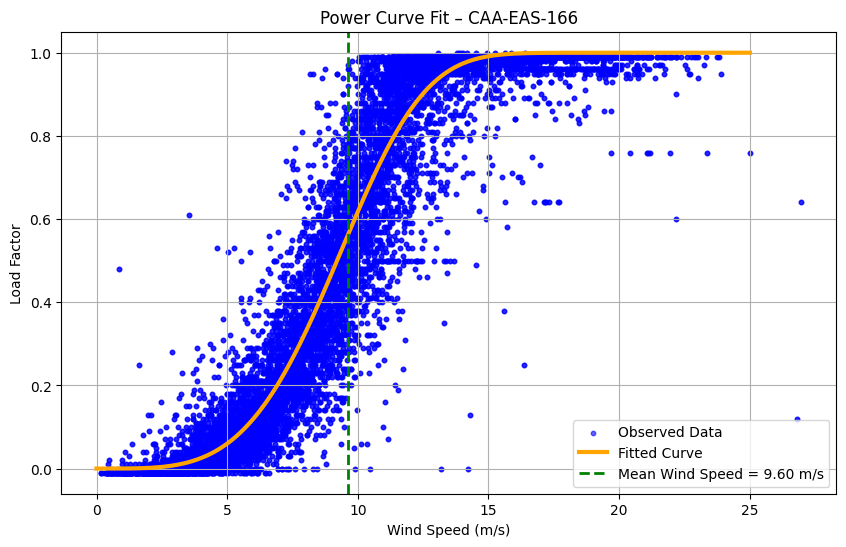

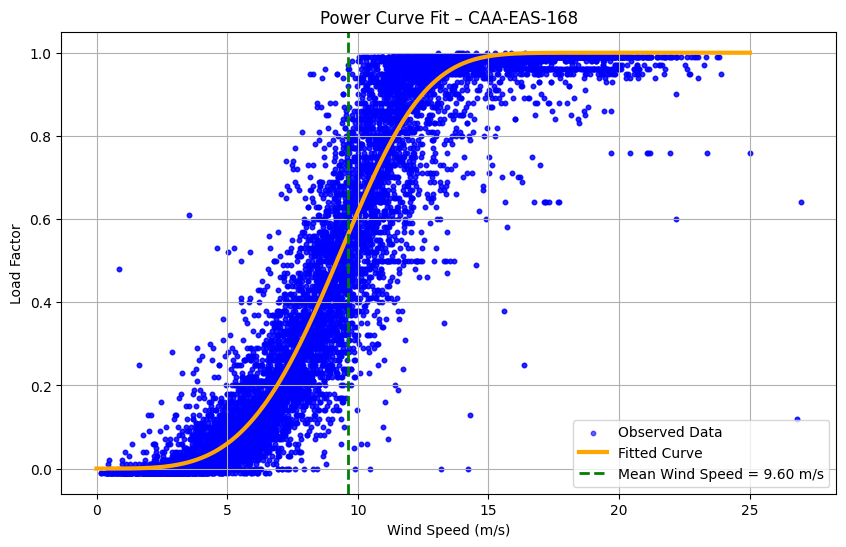

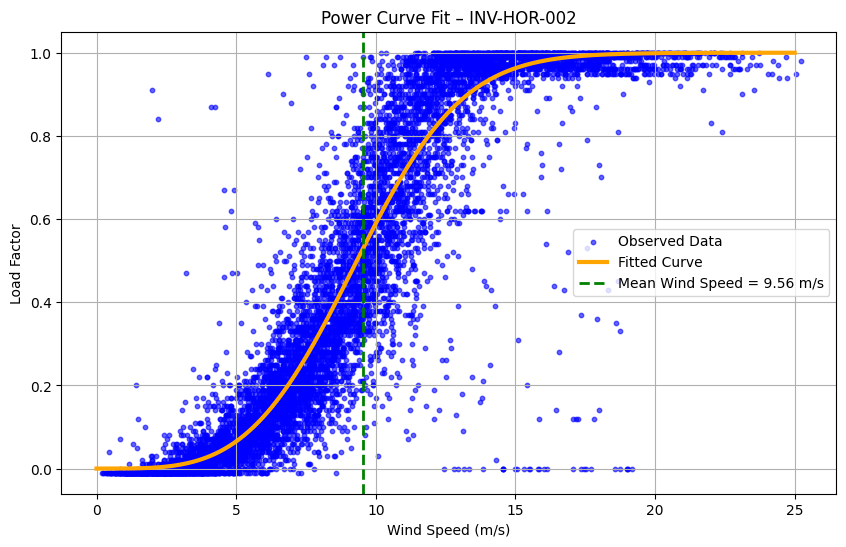

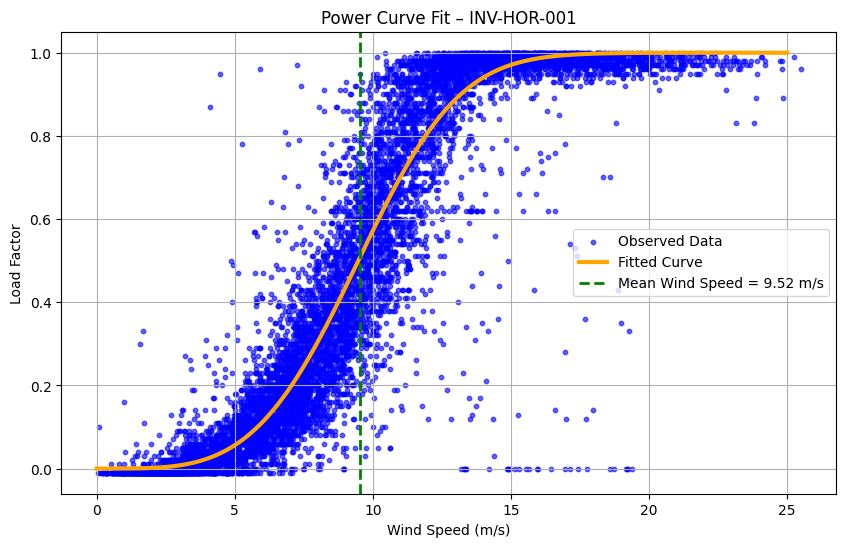

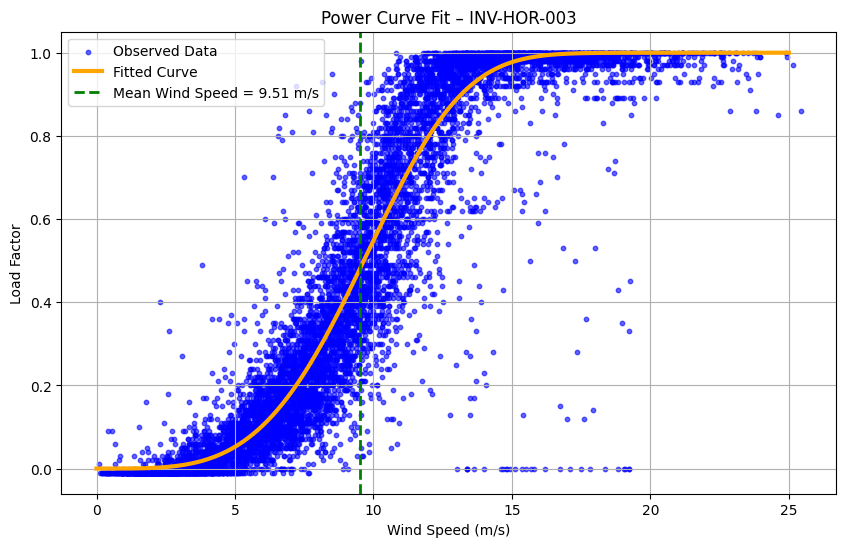

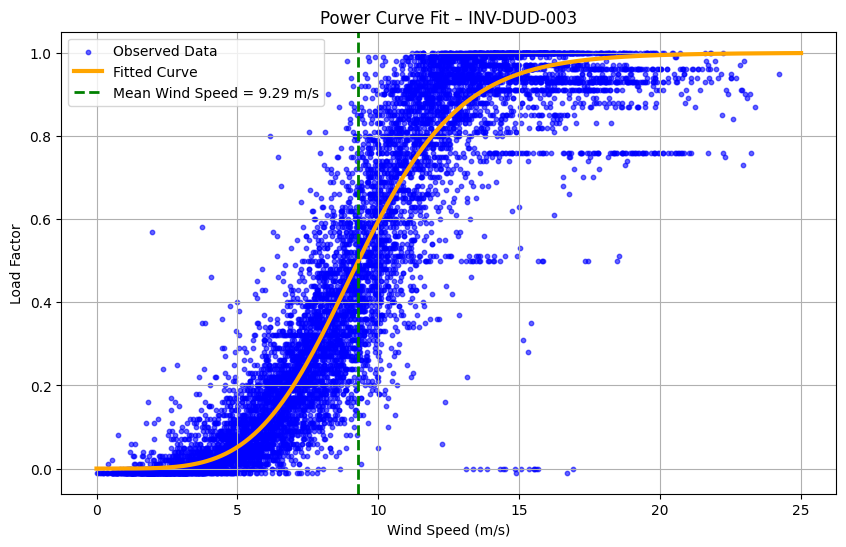

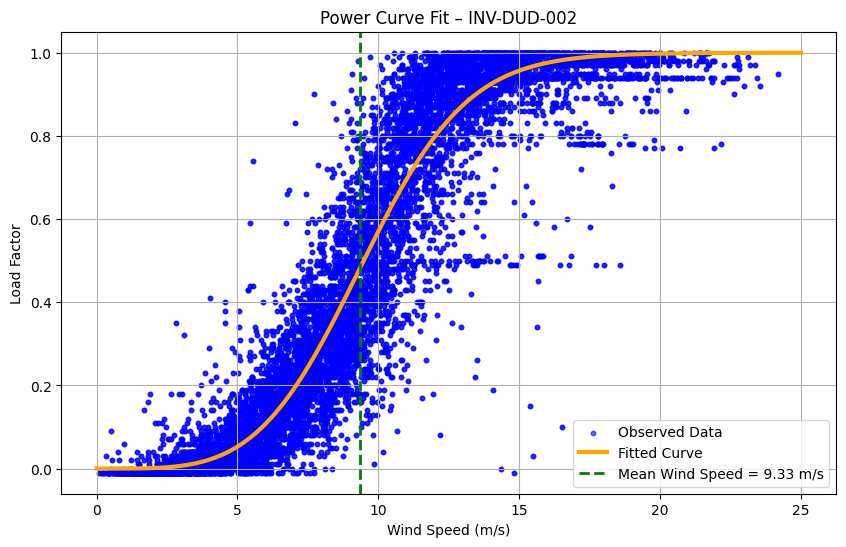

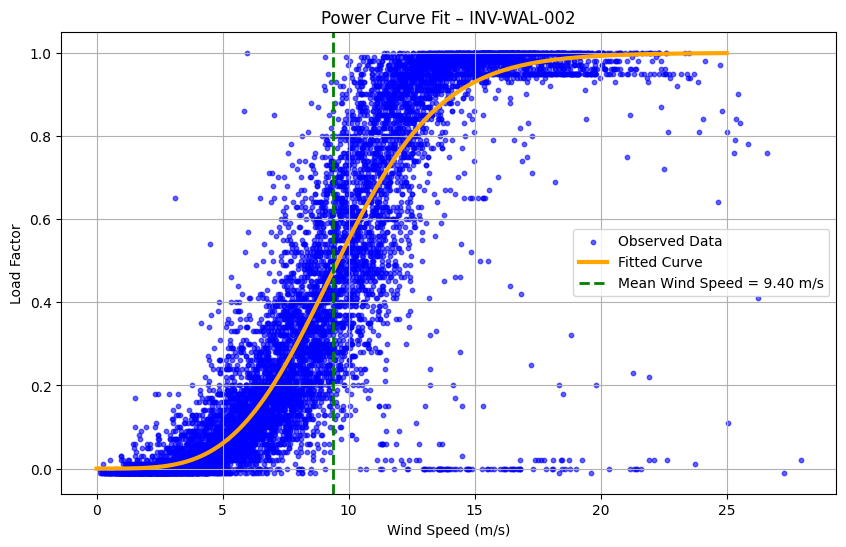

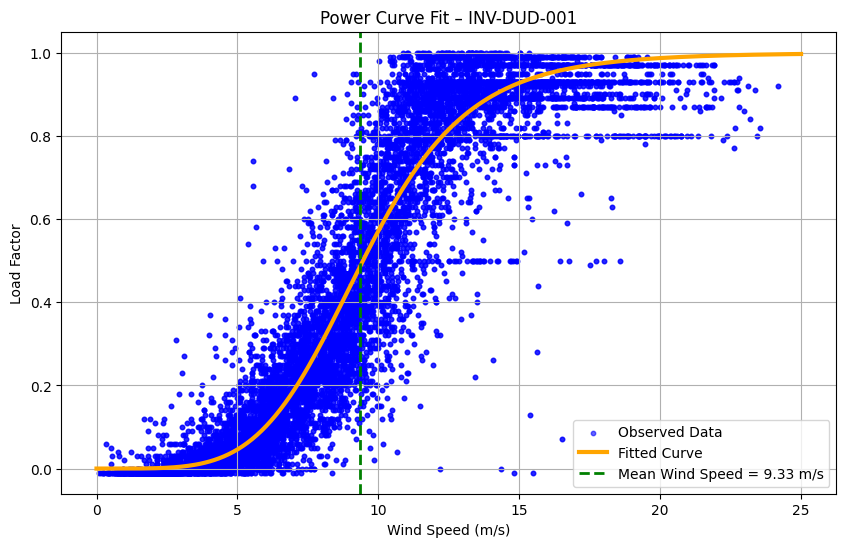

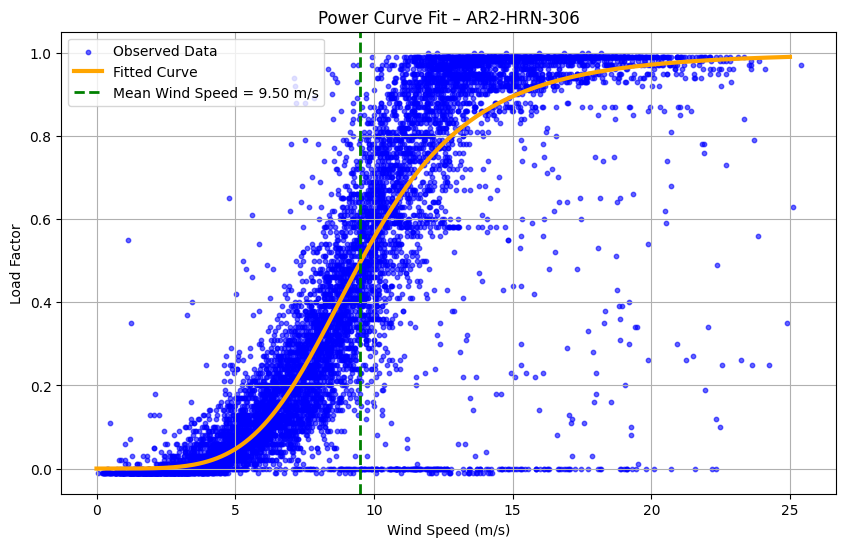

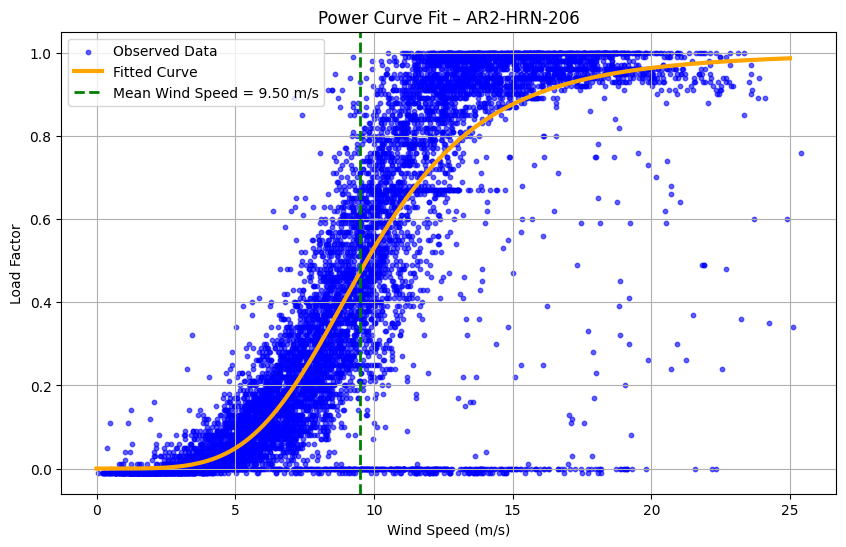

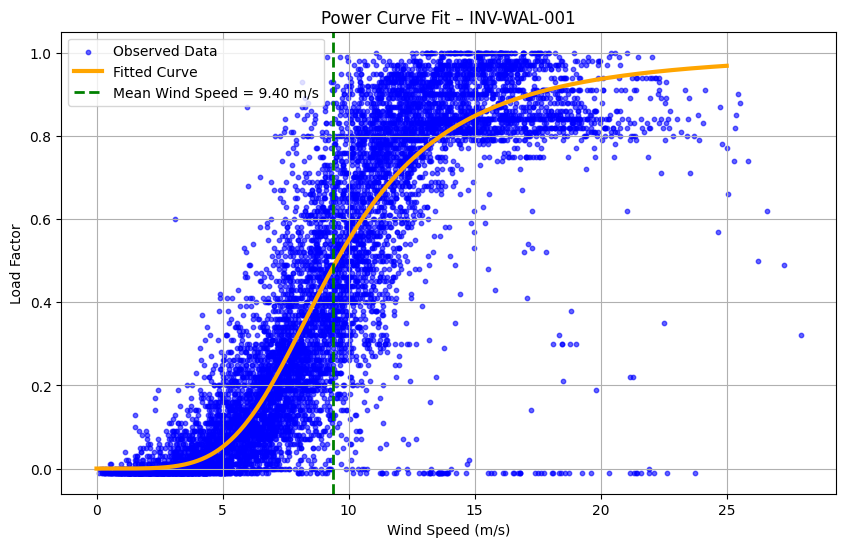

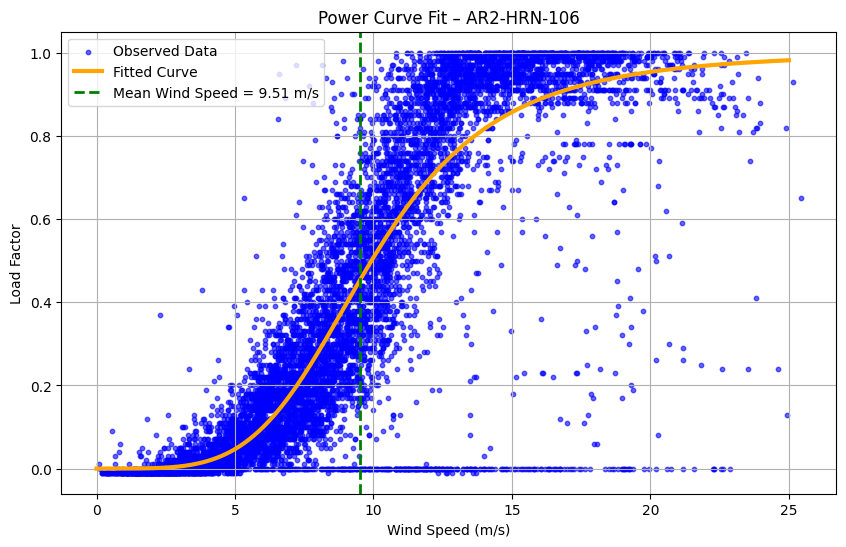

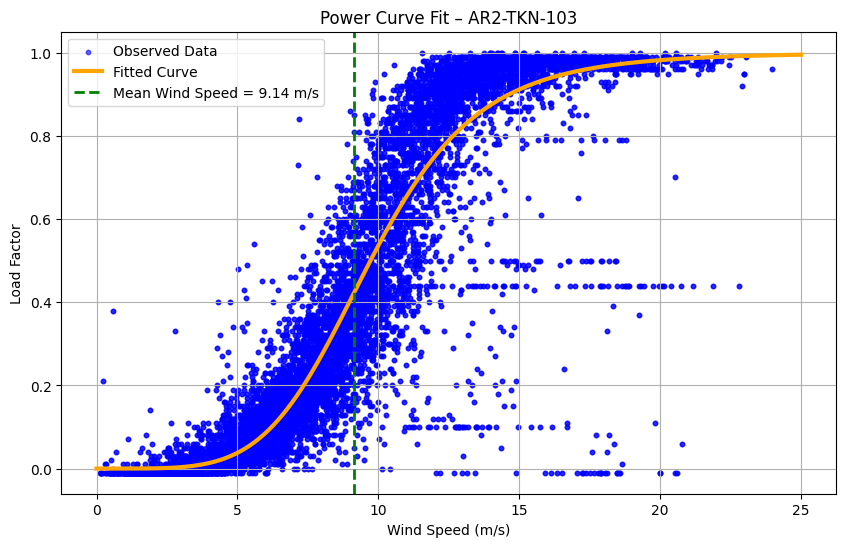

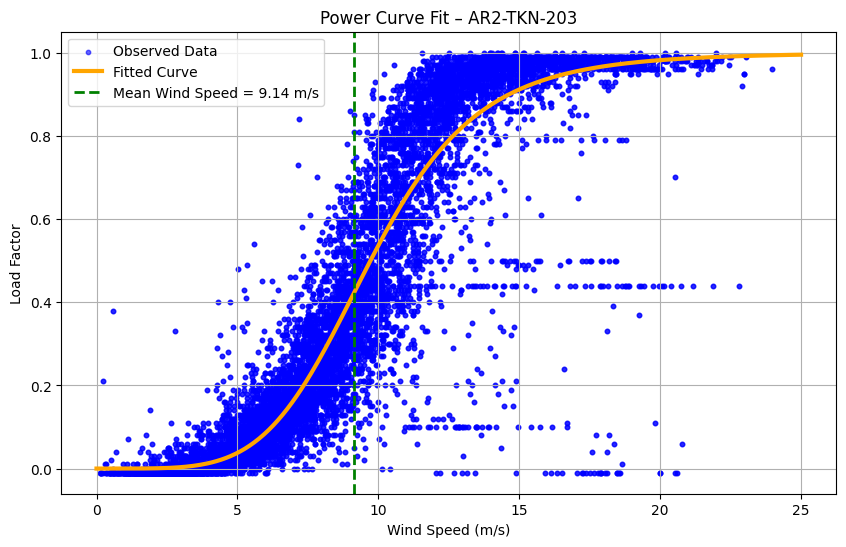

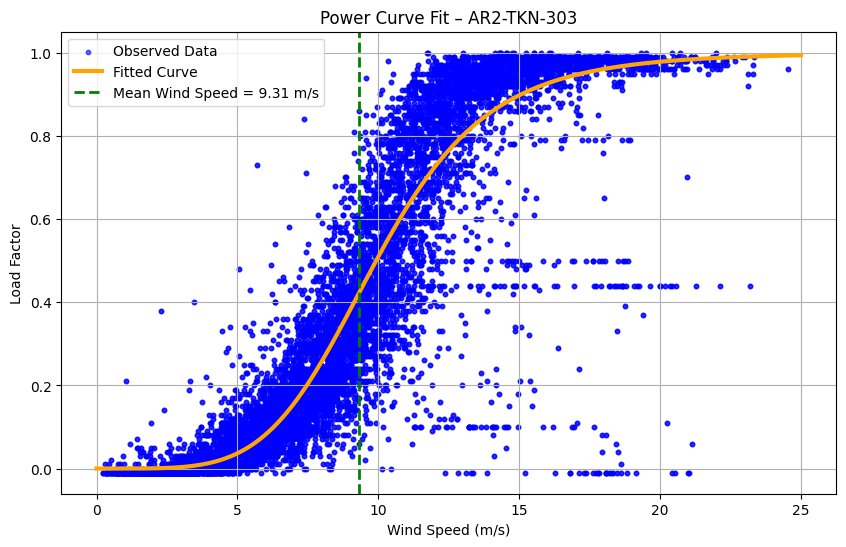

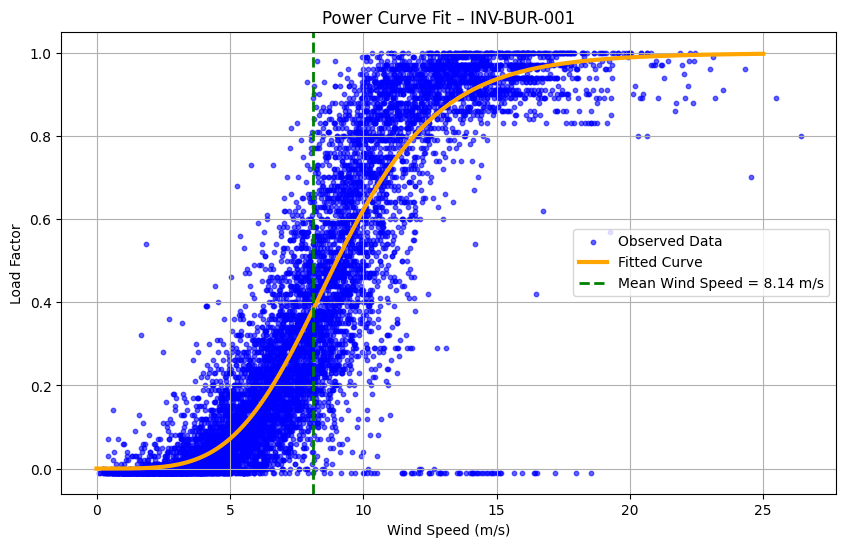

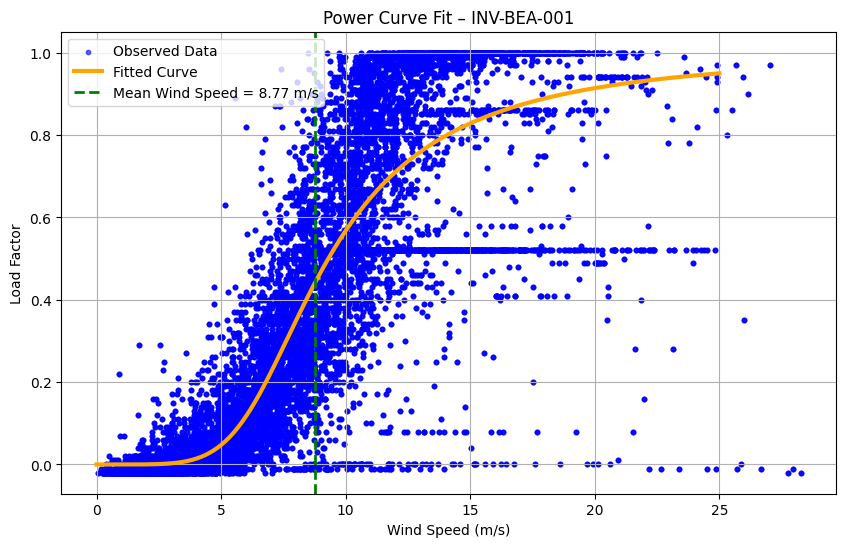

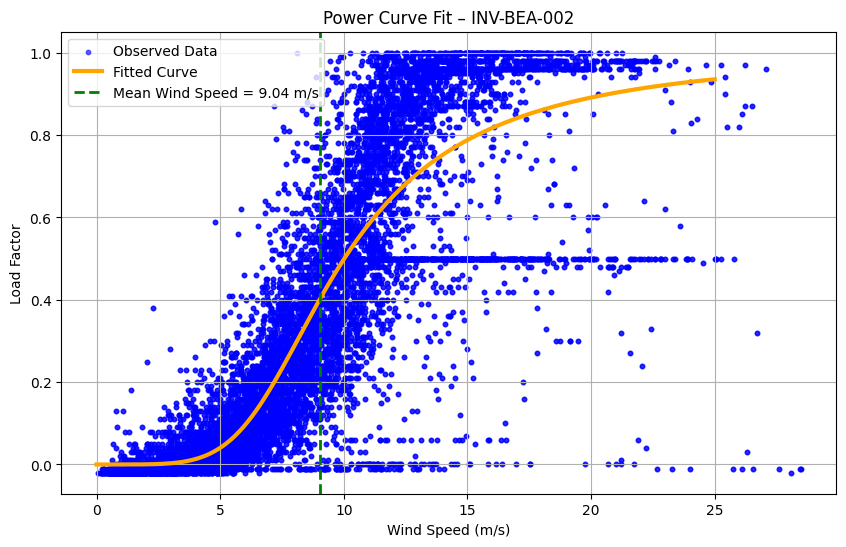

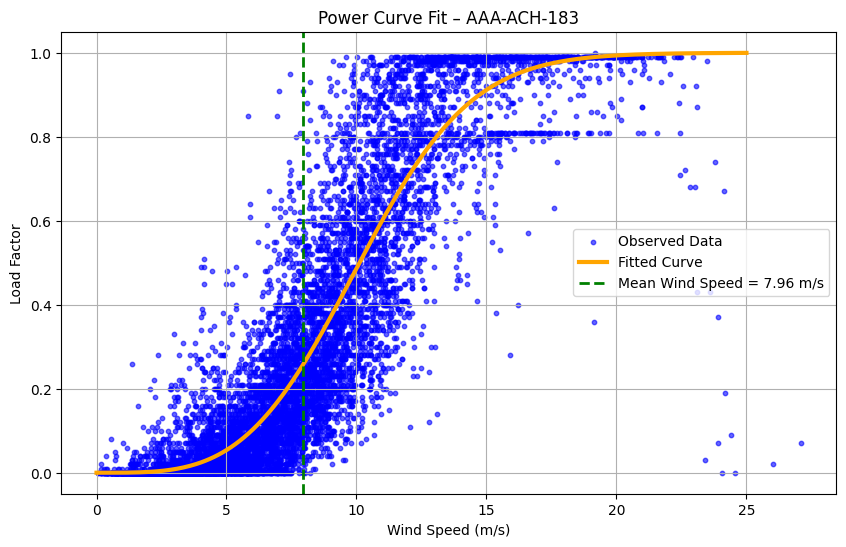

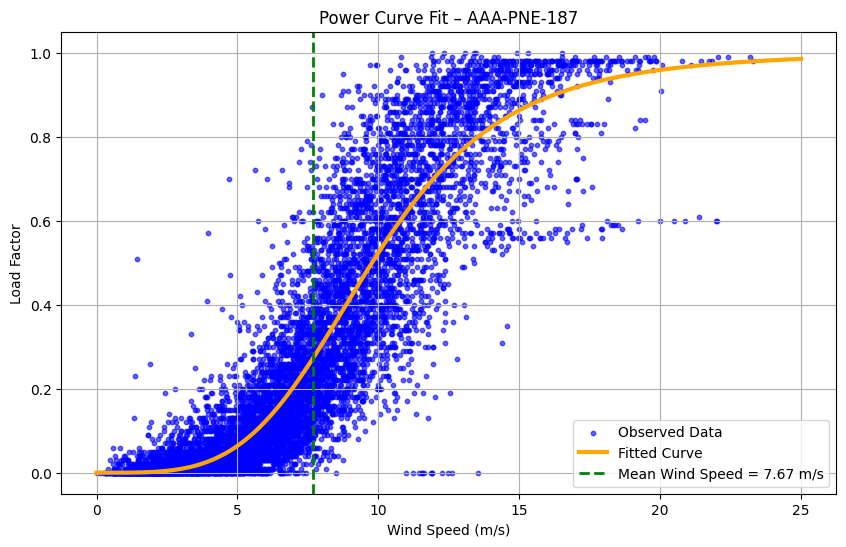

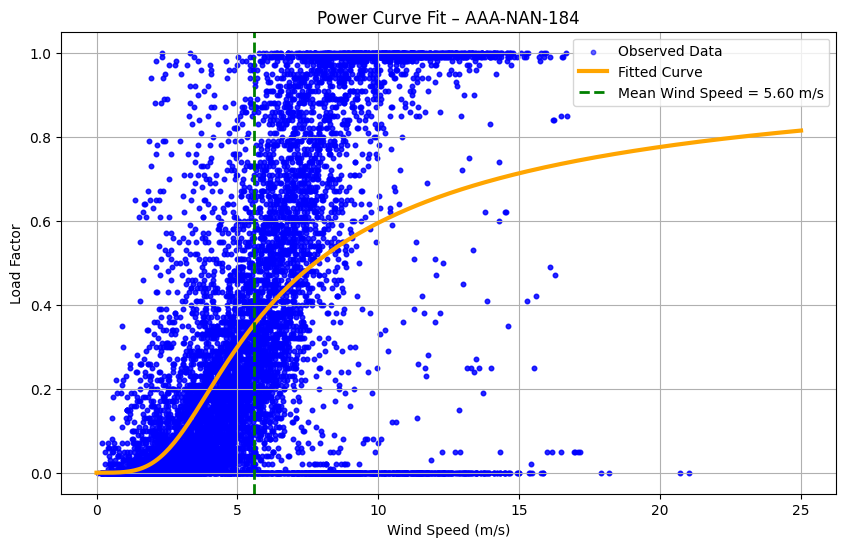

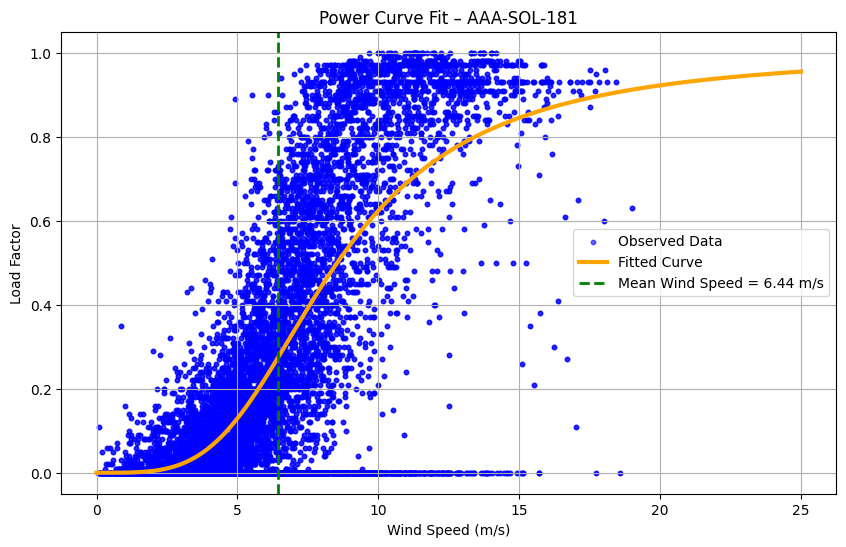

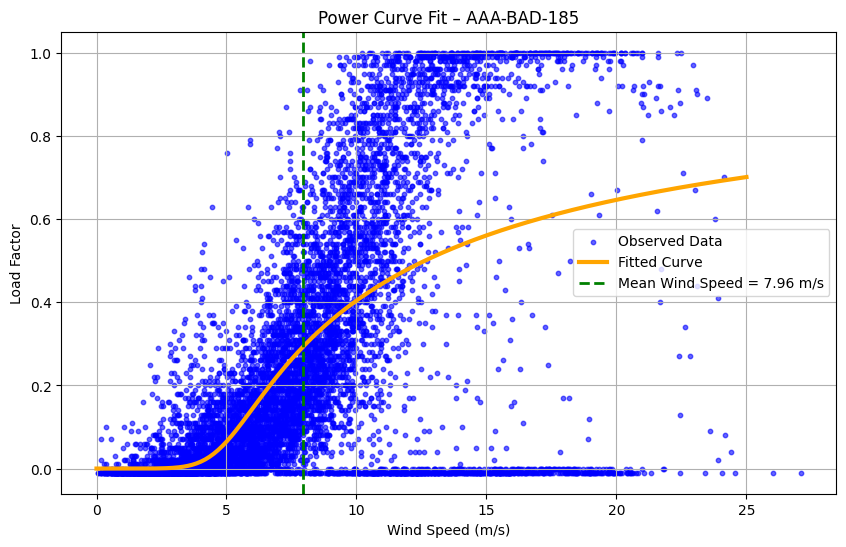

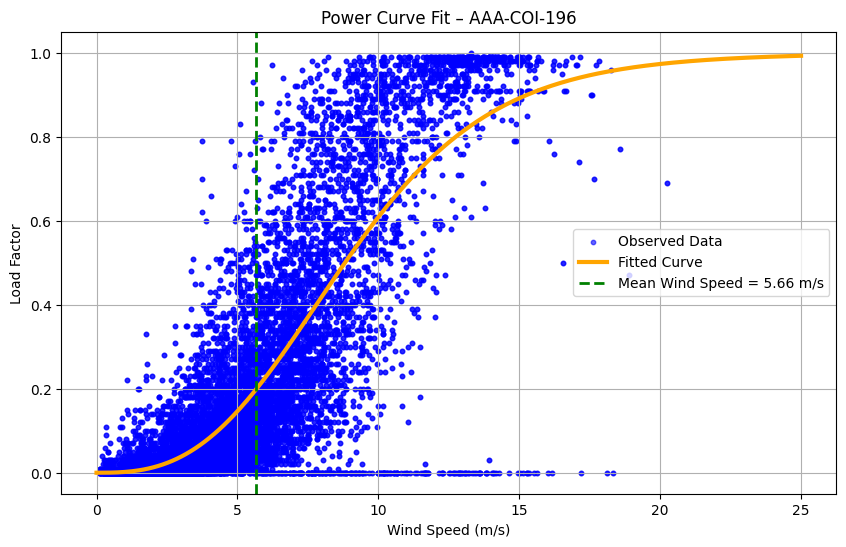

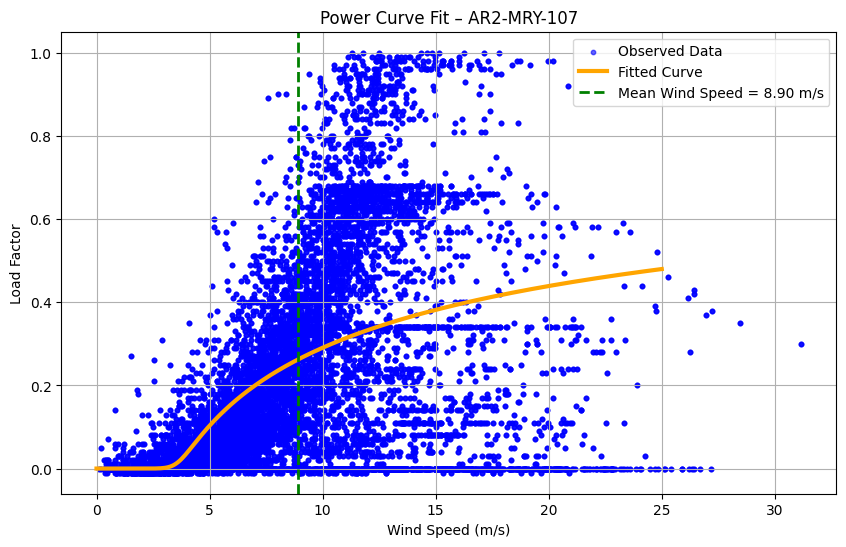

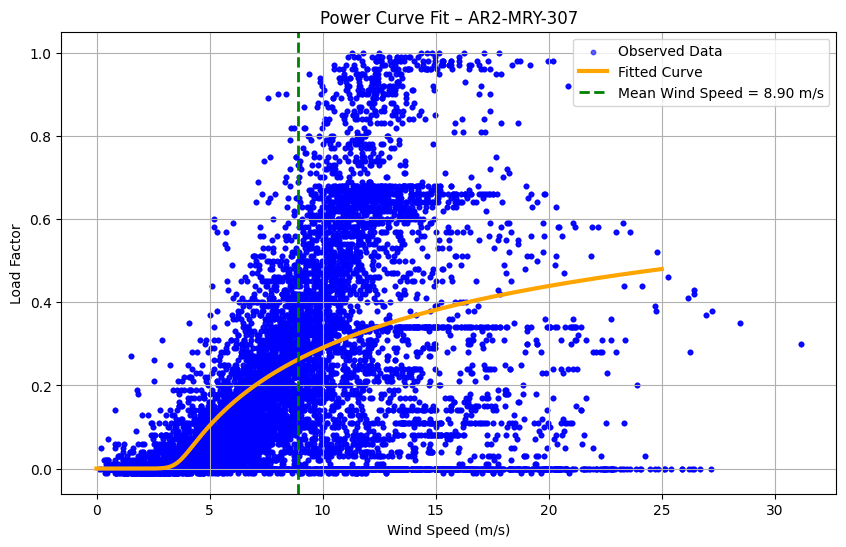

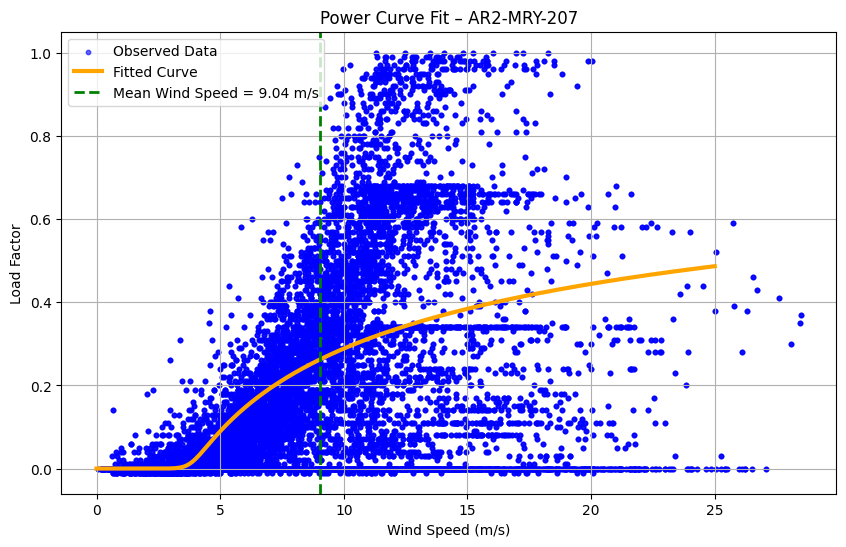

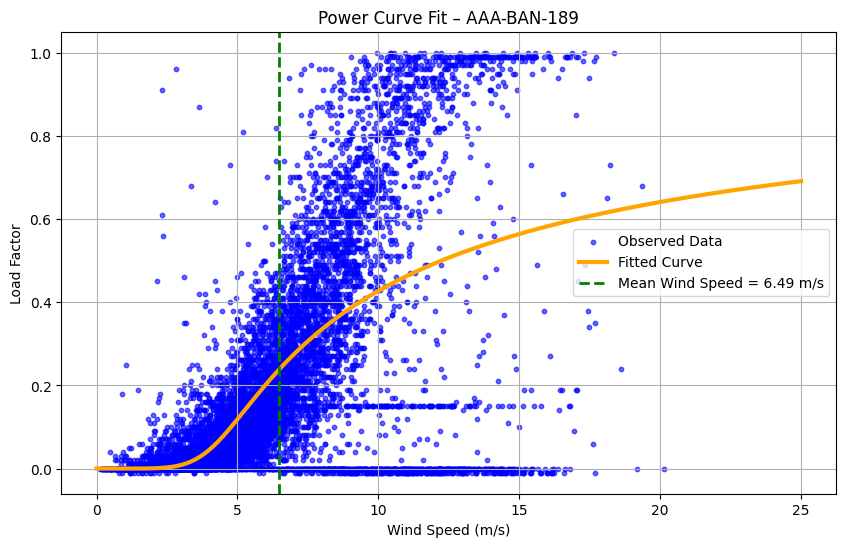

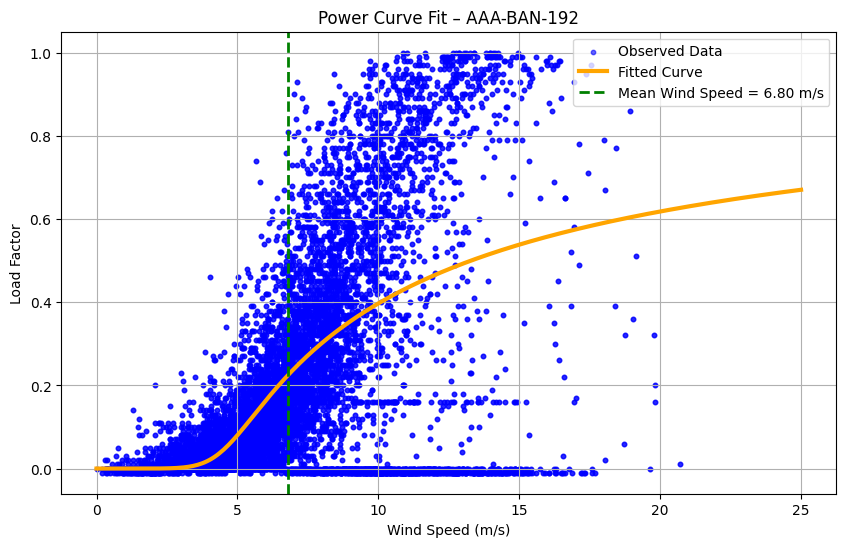

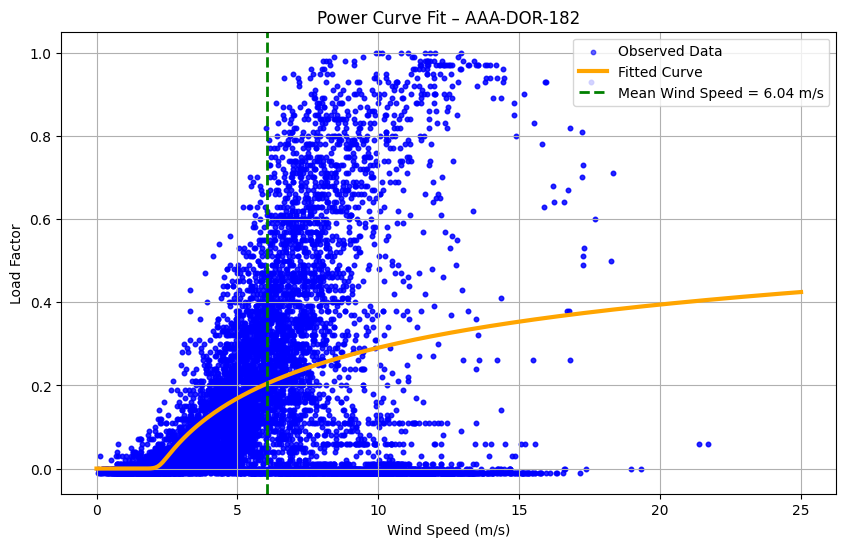

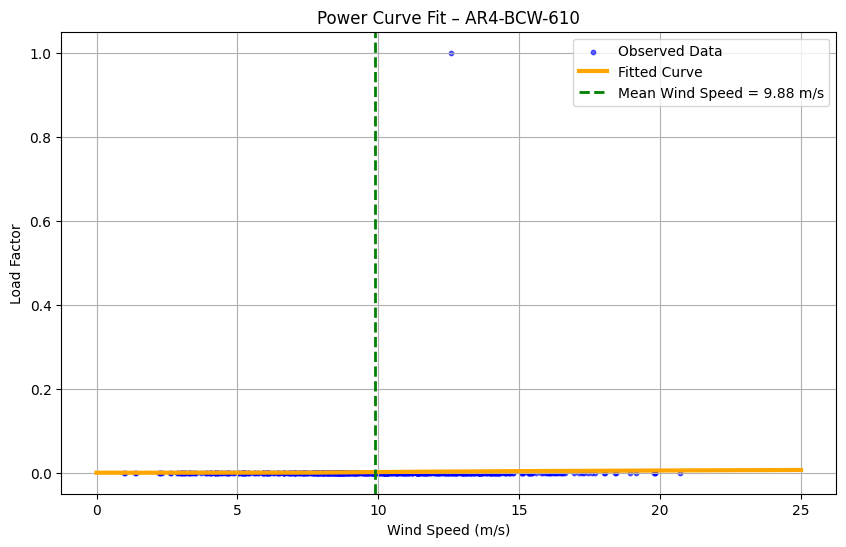

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# ✅ Loop through all CfDs in the summary table
for cfd_id in summary["CFD ID"].dropna().unique():
    # Filter data for this CfD
    o = merged[merged["CFD ID"] == cfd_id]

    # Skip if no data for that CfD
    if o.empty:
        print(f"⚠️ Skipping {cfd_id}: no data in merged.")
        continue

    # Extract fitted parameters from summary
    try:
        row = summary[summary["CFD ID"] == cfd_id].iloc[0]
        b, c, g = row["b"], row["c"], row["g"]
    except IndexError:
        print(f"⚠️ Skipping {cfd_id}: no fitted parameters in summary.")
        continue

    # Skip if any of the parameters are missing or NaN
    if any(pd.isna([b, c, g])):
        print(f"⚠️ Skipping {cfd_id}: invalid fit parameters (NaN).")
        continue

    # --- Logistic function definition ---
    def logistic_function(x, b, c, g):
        a, d = 0, 1
        return d + (a - d) / ((1 + (x / c) ** b) ** g)

    # --- Generate fitted curve ---
    x_vals = np.linspace(0, 25, 300)
    y_vals = logistic_function(x_vals, b, c, g)
    mean_ws = o["Wind Speed"].mean()

    # --- Plot ---
    plt.figure(figsize=(10, 6))
    plt.scatter(
        o["Wind Speed"], o["Load Factor"], s=10, color="blue", alpha=0.6, label="Observed Data"
    )
    plt.plot(x_vals, y_vals, color="orange", lw=3, label="Fitted Curve")
    plt.axvline(
        mean_ws, color="green", linestyle="--", lw=2, label=f"Mean Wind Speed = {mean_ws:.2f} m/s"
    )

    plt.title(f"Power Curve Fit – {cfd_id}")
    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Load Factor")
    plt.legend()
    plt.grid(True)
    plt.show()

In [88]:
# year of data only
# generic curve that is average of all data